# Comparative Analysis of Machine Learning Models for Highly Imbalanced Credit Card Fraud Detection

## 1. Project Objective
This project builds and evaluates multiple machine learning models to classify credit card transactions as legitimate or fraudulent. The dataset is highly imbalanced (fraud makes up less than 0.2%).
We will focus on Recall and F1-score to evaluate the models' ability to minimize False Negatives.

## 2. Dataset Description
- **Source**: OpenML / Kaggle (Credit Card Fraud Detection Dataset)
- **Size**: 284,807 transactions, 492 frauds.
- **Features**: `Amount`, and 28 PCA-transformed features (`V1` to `V28`).
- **Target**: `Class` (0 = Legitimate, 1 = Fraudulent).

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve

from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

# Set visualization style
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## Data Acquisition
We fetch the dataset from OpenML. This provides the exact same Kaggle dataset without requiring API keys.

In [4]:
# Loading the dataset from local CSV
print("Loading dataset from local CSV...")
df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Loading dataset from local CSV...
Dataset shape: (284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Ensure Class column is integer type
if df['Class'].dtype != 'int64' and df['Class'].dtype != 'int32':
    df['Class'] = df['Class'].astype(int)


## Phase 1: Exploratory Data Analysis (EDA)

Class
0    284315
1       492
Name: count, dtype: int64
Fraudulent ratio: 0.173%


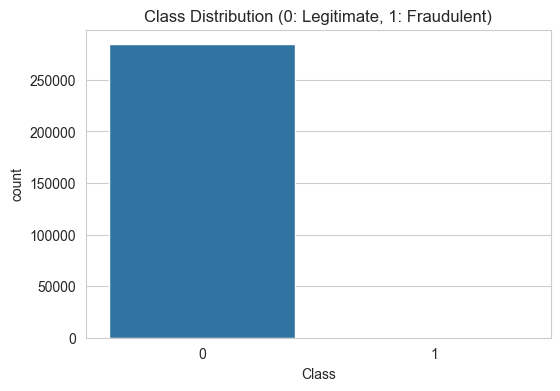

In [6]:
# Class distribution
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"Fraudulent ratio: {class_counts[1] / len(df) * 100:.3f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0: Legitimate, 1: Fraudulent)")
plt.show()

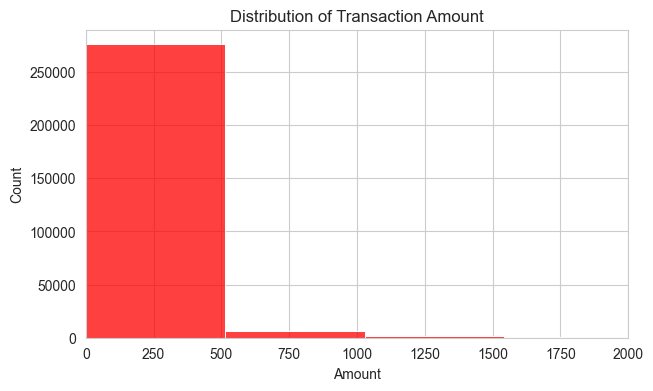

In [7]:
# Amount distribution
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

sns.histplot(df['Amount'], bins=50, color='r')
plt.title('Distribution of Transaction Amount')
plt.xlim([0, 2000]) # Zooming in as most amounts are small
plt.show()

In [8]:
# Check for missing values
print("Missing values in dataset:", df.isnull().sum().max())

Missing values in dataset: 0
